# Using Qrisp circuits with Topologiq

In [1]:
import os
import sys

repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

This notebook offers an example of how to use ***Topologiq*** to perform algorithmic lattice surgery on a Qrisp circuit.

## Qrisp

Let's start by creating a nice circuit using Qrisp. 

We won't be using a famous circuit. Instead, we will focus on using different kinds of gates to see Topologiq in action.

In [2]:
from qrisp import QuantumVariable, h, z, s, t, measure

# Give a catchy name to circuit
circuit_name = "qrisp_single"

# Create a Quantum Variable of 1 single qubit
qrisp_circuit = QuantumVariable(1)

# Add gates
h(qrisp_circuit[0])
t(qrisp_circuit[0])
h(qrisp_circuit[0])
t(qrisp_circuit[0])

# Visualise
print(qrisp_circuit.qs)

QuantumCircuit:
---------------
                 ┌───┐┌───┐┌───┐┌───┐
qrisp_circuit.0: ┤ H ├┤ T ├┤ H ├┤ T ├
                 └───┘└───┘└───┘└───┘
Live QuantumVariables:
----------------------
QuantumVariable qrisp_circuit


## Qrisp - PyZX

The next step is to bring the circuit into Topologiq's general workflow and convert it into PyZX. 

There's a hard and an easy way to do this.
- Hard way: convert the Qrisp circuit to QASM using native Qrisp methods, then import to PyZX using native PyZX methods.
- Easy way: convert Qrisp circuit to Qiskit, then use Topologiq's circuit and ZX graph manager to achieve the conversion. 

We'll go the easy way here.

In [3]:
import pyzx as zx
from topologiq.input.circuit_manager import CircuitManager
from topologiq.input.zx_manager import ZXGraphManager

# -> Qiskit
qc = qrisp_circuit.qs.to_qiskit()

# -> QASM
circuit_manager = CircuitManager()
qasm_str = circuit_manager.add_qiskit_circuit(qc, key="qrisp_circuit")

# KWARGs
kwargs = {
    "first_id_strategy": "centrality-majority",
    "debug": 1,
    "graph_traverse_mode": "bfs",
}

# QASM -> ZX manager
zx_graph_manager = ZXGraphManager()
augmented_zx_graph = zx_graph_manager.add_graph_from_qasm(
    qasm_str=qasm_str, graph_key=circuit_name
)
zx.draw(augmented_zx_graph.zx_graph, labels=True)


=> Ingesting PyZX graph.


## Topologiq

Time for ***Topologiq*** to do its thing. 

This part is also super easy. We just call the `.get_blockgraph` method of the `augmented_zx_graph` we created above. That will return a `BlockGraphManager` object, which is Topologiq's primary object for realised blockgraphs.

> One could also create the `BlockGraphManager` manually and give it the PyZX graph one wants to perform lattice surgery on. But that take a couple more lines of codes and it's not necessary here.


In [4]:
from topologiq.core.graph_manager.graph_manager import BlockGraphManager

# AugmentedZXGraph -> BlockGraph
bgraph_manager = BlockGraphManager(augmented_zx_graph, **kwargs)
bgraph_manager.build()


=> Building BlockGraph.
* First cube.
  - Completed. ID: 2. Kind: XZX, Coords: (0, 0, 0).
* Edge: 2 (Z) --> 0 (O). STANDARD
  - Completed. Vol +: 0. Duration: 0.00s
* Edge: 2 (Z) --> 4 (Z). STANDARD
  - Completed. Vol +: 1. Duration: 0.00s
* Edge: 2 (Z) --> 6 (Z). STANDARD
  - Completed. Vol +: 1. Duration: 0.00s
* Edge: 4 (Z) --> 5 (O). STANDARD
  - Completed. Vol +: 0. Duration: 0.00s
* Edge: 4 (Z) --> 8 (Z). STANDARD
  - Completed. Vol +: 1. Duration: 0.00s
* Edge: 6 (Z) --> 9 (T). STANDARD
  - Completed. Vol +: 1. Duration: 0.00s
* Edge: 6 (Z) --> 11 (X). STANDARD
  - Completed. Vol +: 1. Duration: 0.00s
* Edge: 8 (Z) --> 14 (T). STANDARD
  - Completed. Vol +: 1. Duration: 0.00s
* Edge: 8 (Z) --> 16 (X). STANDARD
  - Completed. Vol +: 1. Duration: 0.00s
* Edge: 11 (X) --> 12 (Y). STANDARD
  - Completed. Vol +: 2. Duration: 0.00s
* Edge: 11 (X) --> 13 (XZ). STANDARD
  - Completed. Vol +: 1. Duration: 0.00s
* Edge: 16 (X) --> 17 (Y). STANDARD
  - Completed. Vol +: 2. Duration: 0.00s

## Output

That's it. You can now visualise the built BlockGraph.

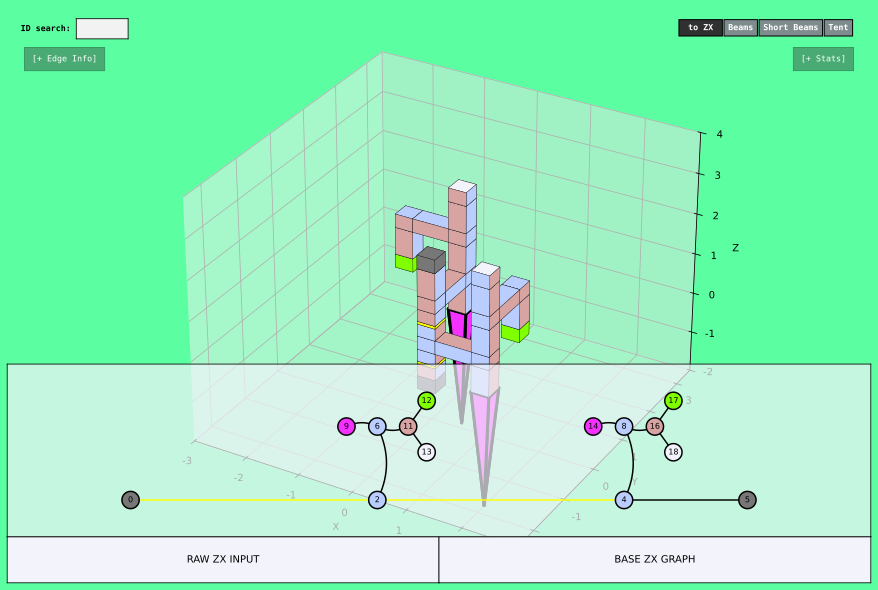

In [5]:
bgraph_manager.draw_blockgraph()

Alternatively, you can also review results by printing the nodes and edges of the `bgraph` attribute of the `BlockGraphManager`.

In [6]:
print("Cubes:")
for n, attrs in bgraph_manager.bgraph.nodes(data=True):
    print(n, attrs)

print("Pipes:")
for u, v, attrs in bgraph_manager.bgraph.edges(data=True):
    print((u, v), attrs)

Cubes:
0 {'zx_block': ZXBlock(zx_type='O', kind='OOO'), 'coords': (0, 0, -1), 'completions': {'degree': 1, 'pending': 0}}
2 {'zx_block': ZXBlock(zx_type='Z', kind='XZX'), 'coords': (0, 0, 0), 'completions': {'degree': 3, 'pending': 0}}
4 {'zx_block': ZXBlock(zx_type='Z', kind='ZXX'), 'coords': (0, 0, 1), 'completions': {'degree': 3, 'pending': 0}}
5 {'zx_block': ZXBlock(zx_type='O', kind='OOO'), 'coords': (0, 0, 2), 'completions': {'degree': 1, 'pending': 0}}
6 {'zx_block': ZXBlock(zx_type='Z', kind='XZX'), 'coords': (1, 0, 0), 'completions': {'degree': 3, 'pending': 0}}
8 {'zx_block': ZXBlock(zx_type='Z', kind='ZXX'), 'coords': (0, 1, 1), 'completions': {'degree': 3, 'pending': 0}}
9 {'zx_block': ZXBlock(zx_type='T', kind='TTO'), 'coords': (1, 0, -1), 'completions': {'degree': 1, 'pending': 0}}
11 {'zx_block': ZXBlock(zx_type='X', kind='XZZ'), 'coords': (1, 0, 1), 'completions': {'degree': 3, 'pending': 0}}
12 {'zx_block': ZXBlock(zx_type='Y', kind='YYO'), 'coords': (1, 1, 0), 'comple

Or write results to a BGRAPH file.

In [7]:
bgraph_manager.write_bgraph(circuit_name=circuit_name)